## Apartado 2. Clasificador de comentarios en subreddits

#### Modelo Baseline

Como modelo baseline vamos a utilizar la representación TF-IDF y entrenaremos un modelo de SVM para la clasificacción.

Lo primero que haremos será crear los conjuntos de entrenamiento y test.

In [1]:
import zstandard as zstd
import json
import argparse
import io
import sys
from pathlib import Path
from datetime import datetime, UTC
import random # Para hacer la distribucion en el tiempo

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]
df = pd.DataFrame()
rows = []

for subreddit in subreddits:
    with open(f"{subreddit}_final.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    for submission in data["submissions"]:
        thread_id = submission["id"]

        for comment in submission["comments"]:
            rows.append({
                "thread_id": thread_id,
                "subreddit": data["subreddits"],
                "comment_id": comment["id"],
                "text": comment["body"]
            })

df = pd.DataFrame(rows)

train_rows = []
val_rows = []

for subreddit in df["subreddit"].unique():
    df_sub = df[df["subreddit"] == subreddit]

    threads = df_sub["thread_id"].unique()

    train_threads, val_threads = train_test_split(
        threads,
        test_size=0.3,
        random_state=42
    )

    train_rows.append(df_sub[df_sub["thread_id"].isin(train_threads)])
    val_rows.append(df_sub[df_sub["thread_id"].isin(val_threads)])

df_train = pd.concat(train_rows, ignore_index=True)
df_val = pd.concat(val_rows, ignore_index=True)

X_train = df_train["text"].apply(lambda x: x.replace("\n", " "))
y_train = df_train["subreddit"]

X_val = df_val["text"].apply(lambda x: x.replace("\n", " "))
y_val = df_val["subreddit"]

Una vez que tenemos definidos los conjuntos de entrenamiento y validación, vamos a crear el modelo de clasificación definiéndolo mediante un pipeline y lo entrenaremos con el conjunto de entrenamiento.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import numpy as np

clf_tfidf = Pipeline([
    ('vect', CountVectorizer()),
    ('tf-idf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0, tol=1e-5))])

clf_tfidf.fit(X_train, y_train)

Pipeline(steps=[('vect', CountVectorizer()), ('tf-idf', TfidfTransformer()),
                ('clf', LinearSVC(random_state=0, tol=1e-05))])

Evaluamos el modelo baseline


In [ ]:
predicted_tfidf = clf_tfidf.predict(X_val)
accuracy_tfidf = np.mean(predicted_tfidf == y_val)

print("Resultados TF-IDF ----- Accuracy:", accuracy_tfidf)
from sklearn import metrics
print(metrics.classification_report(y_val, predicted_tfidf, target_names=subreddits))

Resultados TF-IDF ----- Accuracy: 0.5616666666666666
                 precision    recall  f1-score   support

       onepiece       0.53      0.63      0.57       300
         soccer       0.57      0.56      0.56       300
         gaming       0.67      0.56      0.61       300
         movies       0.51      0.55      0.53       300
leagueoflegends       0.57      0.48      0.52       300
        drawing       0.56      0.59      0.58       300

       accuracy                           0.56      1800
      macro avg       0.57      0.56      0.56      1800
   weighted avg       0.57      0.56      0.56      1800



Ahora imprimimos la matriz de confusión

<Axes: >

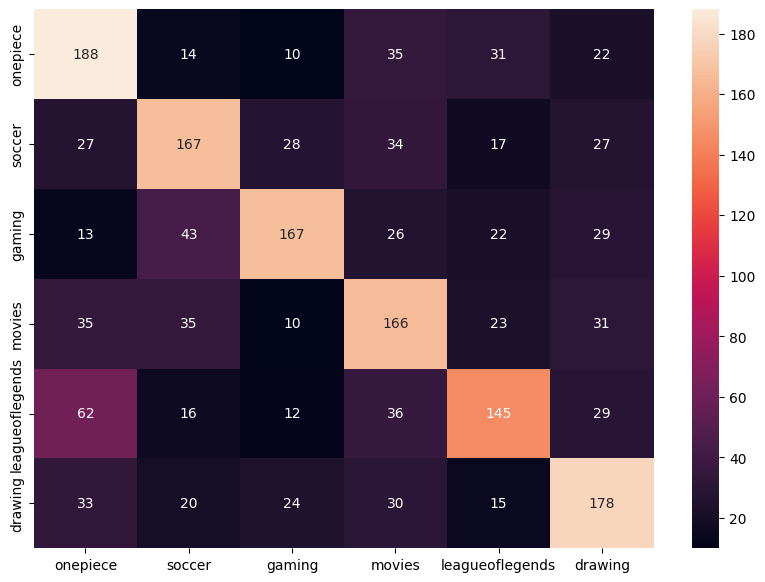

In [ ]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt


array_tfidf = metrics.confusion_matrix(y_val, predicted_tfidf)
df_cm_tfidf = pd.DataFrame(array_tfidf)
id2label = {i: subreddit for i, subreddit in enumerate(subreddits)} # Cambiamos las labels para que sean los nombres de los subreddits
df_cm_tfidf = df_cm_tfidf.rename(id2label, axis=1)
df_cm_tfidf = df_cm_tfidf.rename(id2label, axis=0)

plt.figure(figsize = (10,7))
sn.heatmap(df_cm_tfidf, annot=True, fmt="d")

#### Modelo con Words-Embeddings

La segunda forma que emplearemos para obtener las clasificaciones de los comentarios en su subreddit correspondiente será mediante Words-Embeddings de Fasttext (en inglés) y emplearemos otra vez un SVM para la clasificación.

In [ ]:
# !pip install fasttext
import fasttext
ft_model = fasttext.load_model('crawl-300d-2M-subword.bin')

In [ ]:
fasttext_sentence_train = X_train.apply(lambda x: ft_model.get_sentence_vector(x))
fasttext_sentence_test = X_val.apply(lambda x: ft_model.get_sentence_vector(x))

clf_sentence_embeddings = LinearSVC(random_state=0, tol=1e-5).fit(fasttext_sentence_train.to_list(), y_train)
predicted = clf_sentence_embeddings.predict(fasttext_sentence_test.to_list())
accuracy = np.mean(predicted == y_val)

print("Resultados sentence embeddings Fasttext ----- Accuracy:", accuracy)
from sklearn import metrics
print(metrics.classification_report(y_val, predicted, target_names=subreddits))

Resultados sentence embeddings Fasttext ----- Accuracy: 0.5977777777777777
                 precision    recall  f1-score   support

       onepiece       0.55      0.64      0.59       300
         soccer       0.62      0.54      0.57       300
         gaming       0.65      0.61      0.63       300
         movies       0.60      0.66      0.63       300
leagueoflegends       0.59      0.49      0.54       300
        drawing       0.59      0.65      0.62       300

       accuracy                           0.60      1800
      macro avg       0.60      0.60      0.60      1800
   weighted avg       0.60      0.60      0.60      1800



<Axes: >

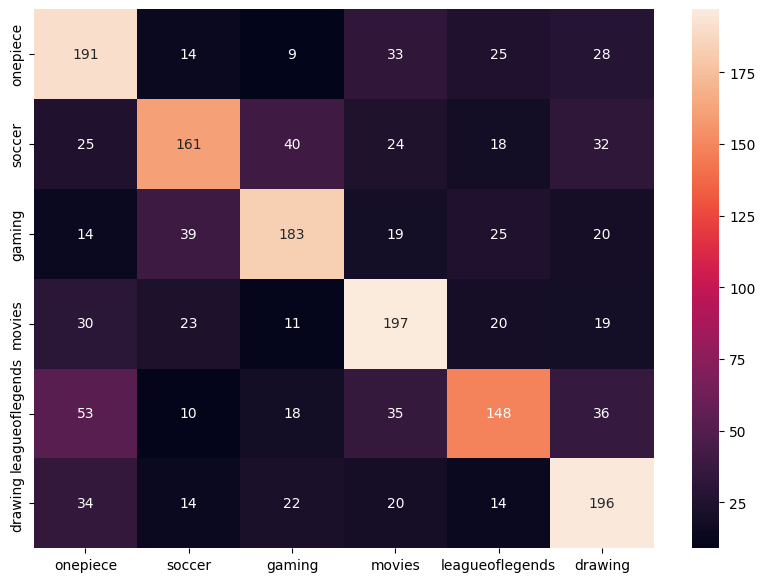

In [ ]:
array_fasttext = metrics.confusion_matrix(y_val, predicted)
df_cm_fasttext = pd.DataFrame(array_fasttext)
id2label = {i: subreddit for i, subreddit in enumerate(subreddits)} # Cambiamos las labels para que sean los nombres de los subreddits
df_cm_fasttext = df_cm_fasttext.rename(id2label, axis=1)
df_cm_fasttext = df_cm_fasttext.rename(id2label, axis=0)

plt.figure(figsize = (10,7))
sn.heatmap(df_cm_fasttext, annot=True, fmt="d")

#### Fine-tuning de un modelo Transformer.

El modelo que vamos a utilizar para hacer el fine-tuning será **FacebookAI/roberta-base**, que es un modelo preentrenado en inglés.

Por tanto, lo primero será cargar el modelo:

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

id2label = {i: subreddit for i, subreddit in enumerate(subreddits)}
label2id = {subreddit: i for i, subreddit in enumerate(subreddits)}

tokenizer = AutoTokenizer.from_pretrained('roberta-base')
model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=len(subreddits),
    id2label= id2label,
    label2id= label2id
).to(device)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

# Tamaño del batch para entrenamiento
batch_train_size = 16

# Tamaño del batch para evaluación
batch_val_size = 32

# Métrica usada para elegir el mejor modelo
metric_name = "eval_f1"

training_args = TrainingArguments (
  output_dir = './results', # donde guardar el modelo entrenado
  logging_dir = './logs', # donde guardar los logs del entrenamiento
  num_train_epochs=3,  # Número de épocas
  eval_strategy="epoch",  # Estrategia de evaluación (epoch / step)
  save_strategy="epoch", # Estrategia de guardado del modelo (epoch / step)
  per_device_train_batch_size = batch_train_size, # Tamaño del batch para entrenamiento
  per_device_eval_batch_size = batch_val_size, # Tamaño del batch para evaluación
  metric_for_best_model=metric_name,  # Métrica usada para elegir el mejor modelo
  save_total_limit=1, # Número máximo de checkpoints a guardar
  load_best_model_at_end=True, # Carga el mejor modelo al final
  report_to="none"  # Desactiva wandb (Weights and Biases)
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# !pip install evaluate
from sklearn.metrics import classification_report
from evaluate import load

def compute_metrics(eval_pred):

  # Utilizamos la F1 para evaluar
  metric = load("f1")

  # Extraemos las predicciones (logits) y las etiquetas reales (labels)
  logits, labels = eval_pred

  # Obtenemos la clase mayoritaria para cada ejemplo
  predictions = np.argmax(logits, axis=-1)


  return metric.compute(predictions=predictions, references=labels, average="weighted")

In [ ]:
import torch

class PLNEDataset(torch.utils.data.Dataset):

  # Guarda los textos tokenizados y sus etiquetas
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  # Devuelve un ejemplo concreto del dataset (sus token y sus etiquetas)
  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  # Devuelve cuántos ejemplos hay en el dataset
  def __len__(self):
    return len(self.labels)

# Tokenizamos los conjuntos de datos
# Los ajustamos al tamaño fijado en el modelo:
#   truncando (truncation) los que son demasiado largos
#   rellenando (padding) los demasiado cortos.
X_train_tokenized = tokenizer(X_train.tolist(), truncation=True, padding = True)
X_val_tokenized = tokenizer(X_val.tolist(), truncation=True, padding = True)

y_train_numerico = [label2id[etiqueta] for etiqueta in y_train.tolist()]
y_val_numerico = [label2id[etiqueta] for etiqueta in y_val.tolist()]
#Creamos los datasets finales
# Preparamos los 3 datasets para hacer el finetuning en el formato esperado por pytorch
train_dataset = PLNEDataset(X_train_tokenized,y_train_numerico)
val_dataset = PLNEDataset(X_val_tokenized, y_val_numerico)


In [ ]:
from transformers import DataCollatorWithPadding, Trainer

# Esto sirve para agrupar el texto en lotes (batches) y añadir el padding necesario automáticamente
# Usamos un DataCollatorWithPadding para padding dinámico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Objeto que simplifica el proceso de entrenamiento y evaluación
trainer = Trainer (
    model = model, # modelo
    args = training_args, # hiperparámetros de entreamiento
    train_dataset = train_dataset, # conjunto de train
    eval_dataset = val_dataset, # conjunto de evaluacion
    compute_metrics = compute_metrics, # funcion de evaluación
    data_collator=data_collator
)

In [ ]:
SEED = 42

# Fijamos la semilla
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Entrenamos el modelo
trainer.train()

trainer.save_model("./modelo_roberta_final")

Epoch,Training Loss,Validation Loss,F1
1,No log,1.035983,0.614518
2,0.933517,0.947576,0.662326
3,0.933517,1.027484,0.668113


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Ahora vamos a cargar el modelo que hemos guardado y el tokenizador.

In [ ]:
# Si ya tenemos el modelo y el tokenizer cargado de las celdas anteriores no es necesario ejecutar esta celda.
# Solo haría falta poner class_model = model.
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
# Cargamos el Tokenizer
tokenizer = AutoTokenizer.from_pretrained("./modelo_roberta_final")

# Cargamos el modelo ya con el FineTuning hecho
class_model = AutoModelForSequenceClassification.from_pretrained("./modelo_roberta_final", num_labels=len(subreddits))

C:\Users\30mmn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Una vez cargado el modelo vamos a obtener las métricas sobre el conjunto de validación.

In [ ]:
from transformers import DataCollatorWithPadding, Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32, 
    report_to="none",              
    do_train=False,   # Asignamos este argumento en False para no tener que entrenar antes de evaluar             
    do_predict=True
)

eval_trainer = Trainer(
    model=class_model,
    data_collator=data_collator,
    args=eval_args,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

eval_trainer.remove_callback(NotebookProgressCallback) # Quitamos este Callback para que no nos de un error al no haber entrenado

predicciones = eval_trainer.predict(val_dataset)
logits = predicciones.predictions
etiquetas_reales = predicciones.label_ids
predicciones_clase = np.argmax(logits, axis=-1)
accuracy = np.mean(predicciones_clase == y_val_numerico)

print("Resultados modelo roberta ----- Accuracy:", accuracy)
print(classification_report(etiquetas_reales, predicciones_clase, target_names=subreddits))
print(json.dumps(eval_trainer.evaluate(), indent=2))

Resultados modelo roberta ----- Accuracy: 0.6694444444444444
                 precision    recall  f1-score   support

       onepiece       0.64      0.57      0.60       300
         soccer       0.66      0.70      0.68       300
         gaming       0.75      0.58      0.66       300
         movies       0.66      0.72      0.69       300
leagueoflegends       0.67      0.72      0.69       300
        drawing       0.65      0.72      0.68       300

       accuracy                           0.67      1800
      macro avg       0.67      0.67      0.67      1800
   weighted avg       0.67      0.67      0.67      1800

{
  "eval_loss": 1.027483344078064,
  "eval_model_preparation_time": 0.001,
  "eval_f1": 0.6681129931294051,
  "eval_runtime": 64.7414,
  "eval_samples_per_second": 27.803,
  "eval_steps_per_second": 0.88,
  "epoch": 0
}


<Axes: >

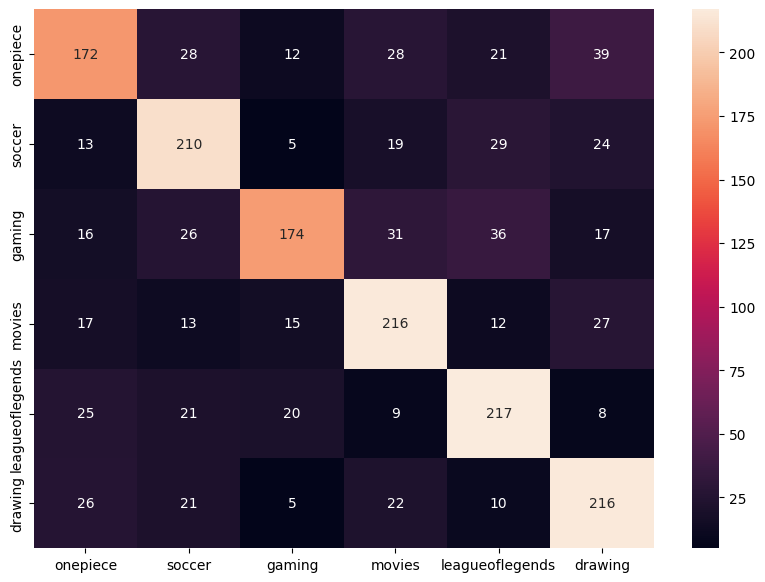

In [ ]:
array_roberta = metrics.confusion_matrix(y_val_numerico, predicciones_clase)
df_cm_roberta = pd.DataFrame(array_roberta)
id2label = {i: subreddit for i, subreddit in enumerate(subreddits)} # Cambiamos las labels para que sean los nombres de los subreddits
df_cm_roberta = df_cm_roberta.rename(id2label, axis=1)
df_cm_roberta = df_cm_roberta.rename(id2label, axis=0)

plt.figure(figsize = (10,7))
sn.heatmap(df_cm_roberta, annot=True, fmt="d")

### Análisis y comparación de los resultados de los 3 modelos

<div style="display: flex; flex-direction: row; align-items: center; justify-content: center; gap: 300px; max-witdh: max-content;">

```text
Resultados TF-IDF ----- Accuracy: 0.5616666666666666
                 precision    recall  f1-score   support

       onepiece       0.53      0.63      0.57       300
         soccer       0.57      0.56      0.56       300
         gaming       0.67      0.56      0.61       300
         movies       0.51      0.55      0.53       300
leagueoflegends       0.57      0.48      0.52       300
        drawing       0.56      0.59      0.58       300

       accuracy                           0.56      1800
      macro avg       0.57      0.56      0.56      1800
   weighted avg       0.57      0.56      0.56      1800
```
<img src="image-1.png" width="500">
</div>

<div style="display: flex; flex-direction: row; align-items: center; justify-content: space-around; gap: 5px; max-witdh: max-content;">

```text
Resultados sentence embeddings Fasttext ----- Accuracy: 0.5977777777777777
                 precision    recall  f1-score   support

       onepiece       0.55      0.64      0.59       300
         soccer       0.62      0.54      0.57       300
         gaming       0.65      0.61      0.63       300
         movies       0.60      0.66      0.63       300
leagueoflegends       0.59      0.49      0.54       300
        drawing       0.59      0.65      0.62       300

       accuracy                           0.60      1800
      macro avg       0.60      0.60      0.60      1800
   weighted avg       0.60      0.60      0.60      1800
```
<img src="image-2.png" width="500">
</div>


<div style="display: flex; flex-direction: row; align-items: center; justify-content: center; gap: 265px; max-witdh: max-content;">

```text
Resultados modelo roberta ----- Accuracy: 0.6694444444444444
                 precision    recall  f1-score   support

       onepiece       0.64      0.57      0.60       300
         soccer       0.66      0.70      0.68       300
         gaming       0.75      0.58      0.66       300
         movies       0.66      0.72      0.69       300
leagueoflegends       0.67      0.72      0.69       300
        drawing       0.65      0.72      0.68       300

       accuracy                           0.67      1800
      macro avg       0.67      0.67      0.67      1800
   weighted avg       0.67      0.67      0.67      1800
```
<img src="image-3.png" width="500">
</div>


Si miramos los resultados obtenidos por los 3 modelos, vemos que el modelo TF-IDF es el modelo más básico obteniendo un accuracy del 56%, mientras que el modelo de roberta es el que mejor clasifica, teniendo un 67% de accuracy. 

Analizando los resultados de este modelo y su matriz de confusión, si miramos el f1-score de cada clase, la clase que mejor compensada está es la de gaming, mientras que la clase de League of Legends es la que menos f1-score tiene, esto es peculiar, ya que League of Legends es un videojuego y podríamos pensar que es porque clasifica los comentarios de este subreddit como gaming; sin embargo, mirando la matriz de confusión vemos que la clase con la que más se confunde es con One Piece. Además, mirando la matriz de confusión de la clase One Piece, vemos que es la clase en la que más aciertos hay, pero si miramos la precision de la clase, vemos que es muy baja, esto es debido a que el clasificador presenta una tendencia a clasificar como One Piece, por lo que cuando el clasificador dice que un comentario es de One Piece acierta solo el 52% de las veces, pero al tener esta tendencia, no se le escapan muchos comentarios que si son de One Piece (es la clase que más recall presenta), por otra parte, la clase de gaming es la que mayor precision tiene, es decir, cuando el clasificador dice que es del subreddit gaming hay una gran probabilidad de que efectivamente, el comentario pertenezca a ese subreddit.

Si ahora miramos los resultados del modelo de fasttext, primero vemos que la accuracy global ha aumentado un 4%. Además, han aumentado también los f1-scores de todas las clases. En este modelo, las clases con mejor f1-score son gaming, al igual que en el modelo anterior, y también movies, esta última siendo la que más recall tiene. Si miramos en este modelo la clase One Piece, vemos que tiene el mismo problema que en el anterior, un recall alto, pero una precision más baja, por lo que este modelo presenta el mismo problema de la tendencia que el anterior. También presenta una gran confusión de la clase League of Legends con la de One Piece al igual que el modelo de TF-IDF, aunque esta vez algo más leve. Podemos conluir que este modelo supone una pequeña mejora con respecto al modelo base, pero no mitiga los problemas ya presentes en el modelo base.

Por último, vamos a analizar los resultados del modelo en el que hacemos un fine-tuning del modelo roberta. En este modelo, se presenta un aumento considerable del accuracy global, llegando hasta el 67%, un 7% más que el modelo de fasttext. Si miramos las métricas por clase, vemos que se ha mitigado el problema con la clase One Piece. En cuanto a la clase de League of Legends, vemos que es la clase en la que más mejora ha habido, llegando a ser la clase con mayor f1-score junto con la clase movies. El único defecto o problema que se puede apreciar en este modelo es que el recall tanto de la clase One Piece como de la clase gaming es algo bajo, es decir, que hay una tendencia negativa del clasificador a clasificar comentarios en estas clases, en cuanto a la clase de One Piece, es curioso que ocurra esto, ya que en los otros modelos sucedía el problema contrario.

Con todo esto, se puede concluir que el mejor modelo es el fine-tuneado, es el que mayor accuracy tiene y el que tiene las clases más compensadas (mayor f1-score por clase).

### **APARTADO 2 - OPCIONAL 1:**

Ahora vamos a analizar los distintos modelos de clasificación utilizados y vamos a realizar un análisis comparativo de distintos tipos de características como el uso de **bigramas**, **trigramas** y **char-n-gramas**:

Para el modelo **BASELINE TF-IDF**:

In [ ]:
print("Resultados TF-IDF ----- Accuracy:", accuracy_tfidf)
from sklearn import metrics
print(metrics.classification_report(y_val, predicted_tfidf))

Con el modelo baseline basado en CountVectorizer + TF-IDF + LinearSVC se obtiene una accuracy de 0.586, lo que significa que clasifica correctamente aproximadamente el 58.6% de los comentarios del conjunto de validación.

Teniendo en cuenta que se trata de un problema con 6 subreddits distintos, este resultado es claramente superior a una clasificación aleatoria.

Analizando las métricas por clase, los mejores resultados se obtienen en drawing y movies, ambos con un F1-score de 0.62, lo que indica que son las categorías que el modelo identifica con mayor precisión y equilibrio entre aciertos y cobertura.

También destaca onepiece con un F1-score de 0.60. En cambio, la clase con peor rendimiento es soccer, con un F1-score de 0.51, lo que sugiere una mayor confusión con otras categorías.

<!--  -->

**BIGRAMAS:**

A continuación, vamos a comparar el modelo **baseline TF-IDF** con el modelo basado **exclusivamente en bigramas**.

In [ ]:
# Modelo SOLO CON BIGRAMAS

clf_tfidf_bigramas = Pipeline([
    ('vect', CountVectorizer(ngram_range=(2, 2), min_df=2)),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0, tol=1e-5))
])

clf_tfidf_bigramas.fit(X_train, y_train)

predicted_tfidf_bigramas = clf_tfidf_bigramas.predict(X_val)
accuraccy_tfidf_bigramas = np.mean(predicted_tfidf_bigramas == y_val)

print("TF-IDF solo bigramas - Accuracy:", accuraccy_tfidf_bigramas)
print(metrics.classification_report(y_val, predicted_tfidf_bigramas))

Como podemos observar comparando los valores de accuracy, **el modelo baseline funciona claramente mejor que el de bigramas**, presentando este un accuracy total del **0.342** frente al **0.586** del baseline, lo que supone una bajada bastante relevante que indica una pérdida importante de rendimiento. Lo mismo ocurre con las métricas globales, ya que el **F1 macro** disminuye también considerablemente.

Por clases, las mejores categorías en el baseline eran "drawing" y "movies" con un F1-score de 0.62, mientras que sólo con bigramas la mejor clase pasa a ser "drawing" pero con un F1-score mucho menor, de 0.43.

Estos resultados indican que utilizar únicamente bigramas hace que el modelo pierda mucha información útil que sí estaba presente en el análisis de palabras individuales (unigramas) del modelo baseline. Como los bigramas son secuencias más específicas, aparecen con muchas menos frecuencia y generan una representación más dispersa, provocando que el clasificador generalice peor.

En conjunto, estos resultados muestran que los unigramas aportan una clasificación mucho más sólida, y que los bigramas por sí solos no son suficientes para clasificar con precisión los comentarios por subreddit.

<!--  -->

**TRIGRAMAS:**

A continuación, vamos a comparar el modelo **baseline TF-IDF** con el modelo basado **exclusivamente en trigramas**.

In [ ]:
# Modelo SOLO TRIGRAMA

clf_tfidf_trigramas = Pipeline([
    ('vect', CountVectorizer(ngram_range=(3, 3), min_df=2)),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0, tol=1e-5))
])

clf_tfidf_trigramas.fit(X_train, y_train)

predicted_tfidf_trigramas = clf_tfidf_trigramas.predict(X_val)
accuracy_tfidf_trigramas = np.mean(predicted_tfidf_trigramas == y_val)

print("TF-IDF solo trigramas - Accuracy:", accuracy_tfidf_trigramas)
print(metrics.classification_report(y_val, predicted_tfidf_trigramas))

Al comparar el modelo baseline TF-IDF con el modelo basado en solo trigramas, podemos obsevar una caída gigantesca del rendimiento, siendo esta peor incluso que la obtenida con el modelo de bigramas, pasando esta vez de un accuracy del **0.586** en el modelo baseline, a **0.23** en el modelo de trigramas, lo cuál es **una caída de más de la mitad**. Esto indica que únicamente se clasifican bien alrededor del 23% de los comentarios, lo cuál sería menos de la mitad de comentarios totales.

Del mismo modo, el F1 macro baja aproximadamente de 0.58 en el baseline a 0.20, reflejando un empeoramiento general en todas las clases.

En el modelo baseline, categorías como drawing y movies obtenían los mejores resultados con F1-score de 0.62, mientras que con trigramas la mejor clase pasa a ser drawing, pero solo con 0.32, muy lejos del rendimiento original.

Este gran empeoramiento se debe a que los trigramas representan secuencias mucho más específicas y menos frecuentes que los unigramas o incluso que los bigramas. Como consecuencia, se genera un vocabulario de secuencias enormes de palabras, donde muchos trigramas aparecen pocas veces, dificultando que el modelo aprenda patrones generales de clasificación.

En definitiva, los resultados muestran que para esta tarea los trigramas por sí solos no resultan adecuados, mientras que el baseline basado en palabras individuales ofrece una representación mucho mejor.

<!--  -->

**CHAR-N-GRAMAS de 3 a 5 carácteres:**

In [ ]:
# Modelo SOLO CHAR-N-GRAMAS de 3 a 5 carácteres

clf_tfidf_char = Pipeline([
    ('vect', CountVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5)),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0, tol=1e-5))
])

clf_tfidf_char.fit(X_train, y_train)

predicted_tfidf_char = clf_tfidf_char.predict(X_val)
accuracy_tfidf__char = np.mean(predicted_tfidf_char == y_val)

print("TF-IDF solo char-n-grams (5) - Accuracy:", accuracy_tfidf__char)
print(metrics.classification_report(y_val, predicted_tfidf_char))

Ahora, comparando el modelo baseline TF-IDF con el modelo basado en **char-n-grams de 3 a 5 caracteres**, podemos observar que ambos ofrecen un rendimiento muy similar, aunque el baseline sigue siendo ligeramente superior. El modelo baseline nos mostraba un accuracy del **0.586**, mientras que el modelo de char-n-gramas obtiene **0.567**, una diferencia bastante pequeña.

Del igual forma, el **F1 macro** pasa de 0.58 en el baseline a 0.57 con char-n-grams, lo que indica que el comportamiento entre clases es bastante parecido.

Analizando por categorías, el modelo de char-n-gramas mejora ligeramente la clasificacón de la categoría "drawing", donde obtiene un 0.64 de F1-score en comparación al 0.62 obtenido en el modelo baseline. Sin embargo en el resto de categorías, los resultados se mantienen iguales o ligeramente mejores en el baseline.

Estos resultados muestran que representar los textos mediante trozos de caracteres pueden ser bastante útiles en entornos como Reddit, donde se abunda el lenguaje de Internet, el cual presenta muchas abreviaturas o errores ortográficos, ya que no depende únicamente de palabras exactas. Aun así, para este caso, la representación normal de unigramas sigue siendo mejor opción para la clasificación de comentarios.

<!--  -->

**UNIGRAMAS + BIGRAMAS:**

In [ ]:
# Modelo UNIGRAMAS + BIGRAMAS

clf_tfidf_unigramas_bigramas = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0, tol=1e-5))
])

clf_tfidf_unigramas_bigramas.fit(X_train, y_train)

predicted_unigramas_bigramas = clf_tfidf_unigramas_bigramas.predict(X_val)
accuracy_unigramas_bigramas = np.mean(predicted_unigramas_bigramas == y_val)

print("TF-IDF unigramas + bigramas - Accuracy:", accuracy_unigramas_bigramas)
print(metrics.classification_report(y_val, predicted_unigramas_bigramas))

Al comparar el modelo baseline TF-IDF con el modelo basado en **unigramas + bigramas**, se observa un comportamiento basante similar al obtenido con el modelo de char-n-grmas. Ambos presentan un rendimiento similar, aunque el baseline vuelve a ser ligeramente superior. El accuracy total obtenido en este caso ha sido del **0.563**

<!--  -->

A continuación, hacemos una **tabla comparativa** de los distintos valores de accuracy y f1-score:

In [ ]:
# Tabla para comparar las accuracy y el f1-socre

resultados_tfidf_ngramas = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Bigramas",
        "Trigramas",
        "Char-n-grams",
        "Unigramas + bigramas"
    ],
    "Accuracy": [
        accuracy_tfidf,
        accuraccy_tfidf_bigramas,
        accuracy_tfidf_trigramas,
        accuracy_tfidf__char,
        accuracy_unigramas_bigramas
    ],
    "F1_macro": [
        metrics.f1_score(y_val, predicted_tfidf, average='macro'),
        metrics.f1_score(y_val, predicted_tfidf_bigramas, average='macro'),
        metrics.f1_score(y_val, predicted_tfidf_trigramas, average='macro'),
        metrics.f1_score(y_val, predicted_tfidf_char, average='macro'),
        metrics.f1_score(y_val, predicted_unigramas_bigramas, average='macro')
    ]
})

resultados_tfidf_ngramas.sort_values(by="Accuracy", ascending=False)

### **APARTADO 2 - OPCIONAL 2**

In [ ]:
import nltk
!pip install demoji
import demoji
import re
from nltk.corpus import stopwords

# Descargar recursos necesarios
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

# Añadimos algunas palabras que son muy comunes en Reddit y no aportan mucho
stop_words.update(['edit', 'thanks', 'post', 'reddit'])

In [ ]:
# Función de limpieza

def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    # Pasamos a minúsculas
    texto = texto.lower()

    # Eliminamos URLs
    texto = re.sub(r'http\S+|www\S+', ' ', texto)

    # Elimiamos emojis
    texto = demoji.replace(texto, "")

    # Separamos por espacios
    palabras = texto.split()

    # Quitamos las stopwords
    palabras_limpias = [p for p in palabras if p not in stop_words]

    # Volvemos a unir el texto en un string
    texto = " ".join(palabras_limpias)

    return texto

In [ ]:
# Añadimos una columna al Dataframe que contenga el texto limpio
df_train['text_clean'] = df_train['text'].apply(limpiar_texto)
df_val['text_clean'] = df_val['text'].apply(limpiar_texto)

In [ ]:
# Comprobamos como ha quedado
df_train.head()

In [ ]:
# Creamos un nuevo X_train y X_val utilizando el texto limpio

X_train_clean = df_train["text_clean"].apply(lambda x: x.replace("\n", " "))
X_val_clean = df_val["text_clean"].apply(lambda x: x.replace("\n", " "))

In [ ]:
# Ahora entrenamos el mismo modelo tf-idf de antes pero utilizando los textos limpios

clf_tfidf_clean = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0, tol=1e-5))
])

clf_tfidf_clean.fit(X_train_clean, y_train)

In [ ]:
# EVALUACIÓN

predicted_tfidf_clean = clf_tfidf_clean.predict(X_val_clean)
accuracy_tfidf_clean = np.mean(predicted_tfidf_clean == y_val)

print("Resultados TF-IDF con limpieza léxica ----- Accuracy:", accuracy_tfidf_clean)

print(metrics.classification_report(y_val, predicted_tfidf_clean, target_names=subreddits))

Como vemos mejora con el texto limpio

Ahora vamos a volver a realizar el modelo